# Sanghelios — EDA y Perfilamiento de donantes
**Hospital General de Medellín**

Análisis exploratorio de datos (EDA) y segmentación de donantes del banco de sangre mediante K-Prototypes.

| | |
|---|---|
| **Proyecto** | Sanghelios |
| **Autor** | Jose Miguel García Vélez |
| **Datos** | [df_banco_sangre_preprocessed.csv](https://github.com/Semillero-Inteligencia-Artificial-EAFIT/Sanghelios/blob/main/data/processed/df_banco_sangre_preprocessed.csv) — Banco de sangre HGM |
| **Período** | 2020 – 2025 |

---

## 0. Configuración

In [1]:
# Librerías
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from kmodes.kprototypes import KPrototypes

# Estilo global
sns.set_theme(style="whitegrid")
plt.rcParams.update(
    {
        "figure.facecolor": "#FAFAFA",
        "axes.facecolor": "#FAFAFA",
        "axes.edgecolor": "#DDDDDD",
        "axes.labelcolor": "#333333",
        "xtick.color": "#444444",
        "ytick.color": "#444444",
        "grid.color": "#E6E6E6",
        "grid.linewidth": 0.8,
        "axes.titleweight": "600",
        "axes.titlesize": 12,
        "axes.labelsize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
    }
)

PALETA = ["#185FA5", "#A32D2D", "#3B6D11", "#D49A3A", "#8E5BA3"]
MESES = [
    "Ene",
    "Feb",
    "Mar",
    "Abr",
    "May",
    "Jun",
    "Jul",
    "Ago",
    "Sep",
    "Oct",
    "Nov",
    "Dic",
]
C_SEXO = {"f": "#A32D2D", "m": "#185FA5"}
C_CLUSTER = {0: "#A32D2D", 1: "#185FA5", 2: "#3B6D11"}


def style_axes(ax, title=None, xlabel=None, ylabel=None, grid_axis="y"):
    if grid_axis:
        ax.grid(axis=grid_axis, linewidth=0.6, alpha=0.6)
        ax.set_axisbelow(True)
    if title:
        ax.set_title(title, loc="left")
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color("#ddd")


def label_bars(
    ax, bars, labels=None, orientation="v", offset_ratio=0.03, fontsize=8, color="#444"
):
    if not len(bars):
        return
    if orientation == "v":
        heights = [b.get_height() for b in bars]
        offset = max(heights) * offset_ratio if heights else 0
        if labels is None:
            labels = [f"{h:,.0f}" for h in heights]
        for bar, lbl in zip(bars, labels):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + offset,
                lbl,
                ha="center",
                va="bottom",
                fontsize=fontsize,
                color=color,
            )
    else:
        widths = [b.get_width() for b in bars]
        offset = max(widths) * offset_ratio if widths else 0
        if labels is None:
            labels = [f"{w:,.0f}" for w in widths]
        for bar, lbl in zip(bars, labels):
            ax.text(
                bar.get_width() + offset,
                bar.get_y() + bar.get_height() / 2,
                lbl,
                ha="left",
                va="center",
                fontsize=fontsize,
                color=color,
            )

## 1. Carga y limpieza

In [2]:
# Cargar datos
project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

ruta = project_root / "data" / "processed" / "df_banco_sangre_preprocessed.csv"

df = pd.read_csv(ruta)

# Limpieza básica
df = df.drop(columns=["Unnamed: 0"], errors="ignore")
df = df[df["imc"] <= 80].reset_index(drop=True)  # outlier IMC confirmado
df["fecha_extraccion"] = pd.to_datetime(df["fecha_extraccion"], errors="coerce")
df["año"] = df["fecha_extraccion"].dt.year
df["mes"] = df["fecha_extraccion"].dt.month

print(f"Dimensiones:  {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(
    f"Período:      {df['fecha_extraccion'].min().date()} → {df['fecha_extraccion'].max().date()}"
)
print(f"Nulos totales: {df.isnull().sum().sum()}")
df.dtypes

Dimensiones:  25,564 filas × 11 columnas
Período:      2020-01-02 → 2025-06-27
Nulos totales: 0


fecha_extraccion      datetime64[ns]
rh                            object
barrio                        object
comuna_o_municipio            object
edad                           int64
sexo                          object
cobertura                    float64
pct_poblacion                float64
imc                          float64
año                            int32
mes                            int32
dtype: object

---
## 2. EDA — Análisis exploratorio
### 2.1 Estadísticas descriptivas

In [3]:
print("Numéricas:")
print(df.describe().round(2))
print("\nCategóricas:")
print(df.describe(include=["object"]))

Numéricas:
                    fecha_extraccion      edad  cobertura  pct_poblacion  \
count                          25564  25564.00   25564.00       25564.00   
mean   2022-06-09 17:15:43.514317056     37.35      65.05          36.28   
min              2020-01-02 00:00:00     18.00       0.80           0.30   
25%              2021-02-16 00:00:00     27.00      28.80          28.00   
50%              2022-02-23 00:00:00     36.00      87.90          52.10   
75%              2023-04-27 00:00:00     47.00      87.90          52.10   
max              2025-06-27 00:00:00     65.00     100.00          52.10   
std                              NaN     12.40      32.60          18.64   

            imc       año       mes  
count  25564.00  25564.00  25564.00  
mean      26.35   2021.97      6.11  
min       15.15   2020.00      1.00  
25%       23.46   2021.00      3.00  
50%       25.78   2022.00      6.00  
75%       28.70   2023.00      9.00  
max       57.24   2025.00     12.00  


### 2.2 Tendencia temporal

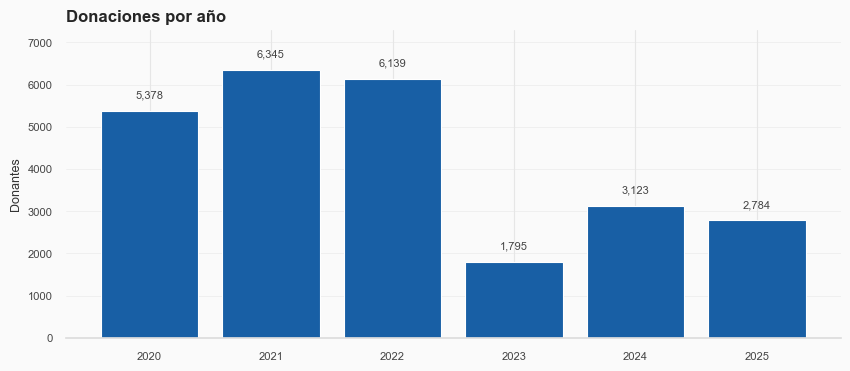

In [4]:
# Donaciones por año
don_año = df["año"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(
    don_año.index.astype(int),
    don_año.values,
    color=PALETA[0],
    edgecolor="white",
    linewidth=0.8,
)
label_bars(ax, bars, labels=[f"{int(v):,}" for v in don_año.values], offset_ratio=0.04)
ax.margins(y=0.15)
style_axes(ax, title="Donaciones por año", ylabel="Donantes", grid_axis="y")
plt.show()

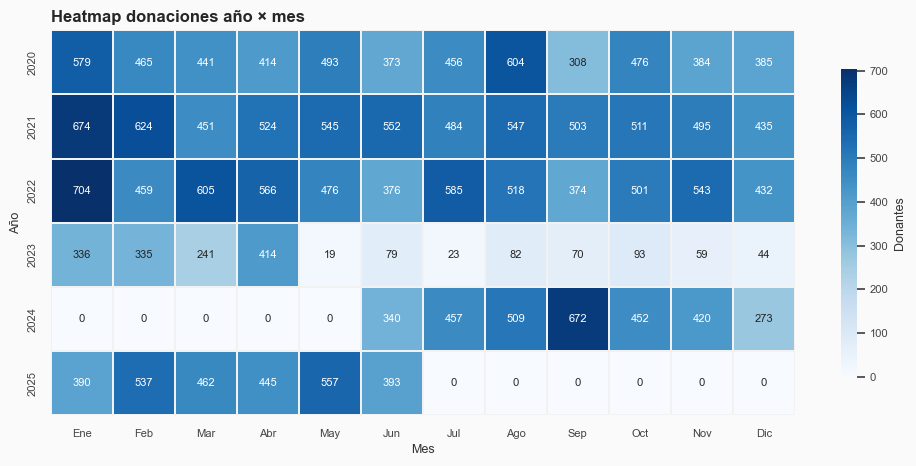

In [5]:
# Heatmap año × mes
pivot = df.groupby(["año", "mes"]).size().unstack(fill_value=0)
pivot = pivot.reindex(columns=range(1, 13), fill_value=0)
pivot.columns = MESES
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    pivot,
    ax=ax,
    cmap="Blues",
    linewidths=0.3,
    linecolor="#F2F2F2",
    annot=True,
    fmt="d",
    annot_kws={"size": 8},
    cbar_kws={"shrink": 0.8, "label": "Donantes"},
)
ax.set_title("Heatmap donaciones año × mes", loc="left")
ax.set_xlabel("Mes")
ax.set_ylabel("Año")
plt.show()

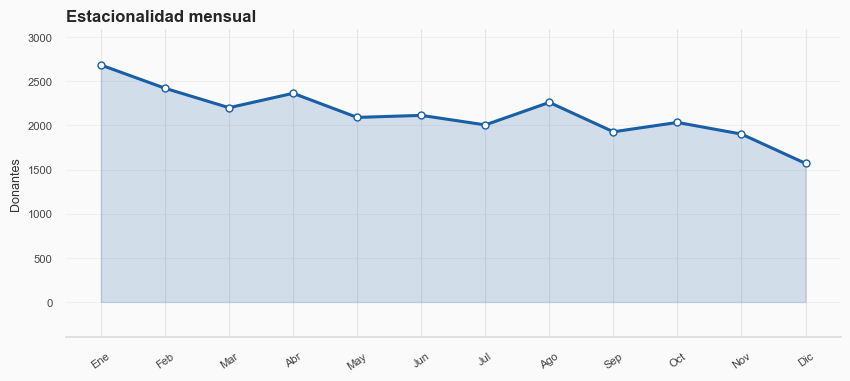

In [6]:
# Estacionalidad mensual
don_mes = df.groupby("mes").size().reindex(range(1, 13), fill_value=0)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(
    don_mes.index,
    don_mes.values,
    color=PALETA[0],
    linewidth=2.2,
    marker="o",
    markersize=5,
    markerfacecolor="white",
    markeredgewidth=1,
)
ax.fill_between(don_mes.index, don_mes.values, alpha=0.18, color=PALETA[0])
ax.set_xticks(range(1, 13))
ax.set_xticklabels(MESES, fontsize=8, rotation=35)
ax.margins(y=0.15)
style_axes(ax, title="Estacionalidad mensual", ylabel="Donantes", grid_axis="y")
plt.show()

> **Hallazgo — Tendencia temporal:** Las donaciones alcanzaron su pico en 2021–2022 (~6.300/año) y cayeron en 2023 (1.795) por escasez severa de mayo a diciembre (valores entre 19 y 93). Aunque 2024–2025 muestran recuperación parcial (~3.000), siguen por debajo del nivel histórico normal. El patrón estacional muestra que **diciembre es el mes más crítico** (~1.560 acumuladas) y enero el más alto (~2.650). Las campañas de Sanghelios deben activarse en **noviembre** para anticipar la caída.

### 2.3 Perfil demográfico

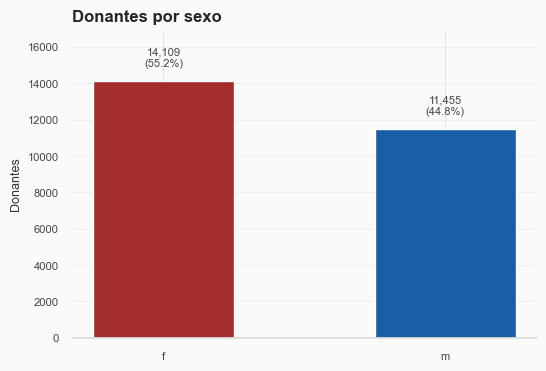

In [7]:
# Donantes por sexo
sexo = df["sexo"].value_counts(dropna=False)
labels = sexo.index.astype(str).tolist()
colors = [C_SEXO.get(l, PALETA[0]) for l in labels]
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, sexo.values, color=colors, edgecolor="white", width=0.5)
total = sexo.values.sum()
label_bars(
    ax,
    bars,
    labels=[f"{v:,}\n({v/total*100:.1f}%)" for v in sexo.values],
    offset_ratio=0.05,
)
ax.margins(y=0.2)
style_axes(ax, title="Donantes por sexo", ylabel="Donantes", grid_axis="y")
plt.show()

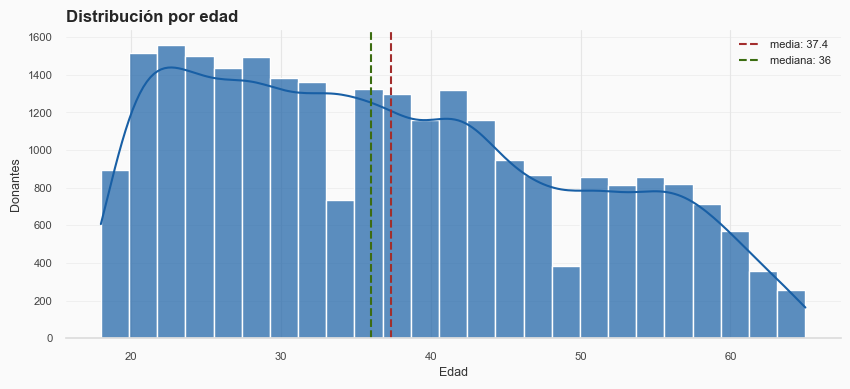

In [8]:
# Distribución por edad
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(
    df["edad"], bins=25, kde=True, color=PALETA[0], edgecolor="white", alpha=0.7, ax=ax
)
ax.axvline(
    df["edad"].mean(),
    color=PALETA[1],
    linestyle="--",
    linewidth=1.5,
    label=f"media: {df['edad'].mean():.1f}",
)
ax.axvline(
    df["edad"].median(),
    color=PALETA[2],
    linestyle="--",
    linewidth=1.5,
    label=f"mediana: {df['edad'].median():.0f}",
)
style_axes(
    ax, title="Distribución por edad", xlabel="Edad", ylabel="Donantes", grid_axis="y"
)
ax.legend(fontsize=8, frameon=False)
plt.show()

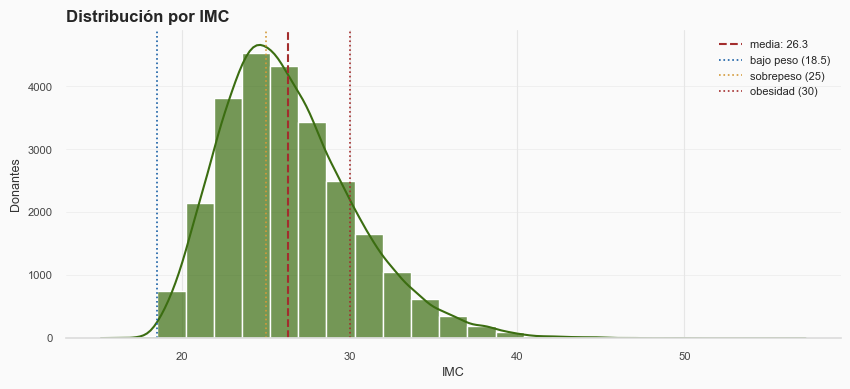

In [9]:
# Distribución por IMC
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(
    df["imc"], bins=25, kde=True, color=PALETA[2], edgecolor="white", alpha=0.7, ax=ax
)
ax.axvline(
    df["imc"].mean(),
    color=PALETA[1],
    linestyle="--",
    linewidth=1.5,
    label=f"media: {df['imc'].mean():.1f}",
)
ax.axvline(
    18.5, color=PALETA[0], linestyle=":", linewidth=1.2, label="bajo peso (18.5)"
)
ax.axvline(25.0, color=PALETA[3], linestyle=":", linewidth=1.2, label="sobrepeso (25)")
ax.axvline(30.0, color=PALETA[1], linestyle=":", linewidth=1.2, label="obesidad (30)")
style_axes(
    ax, title="Distribución por IMC", xlabel="IMC", ylabel="Donantes", grid_axis="y"
)
ax.legend(fontsize=8, frameon=False)
plt.show()

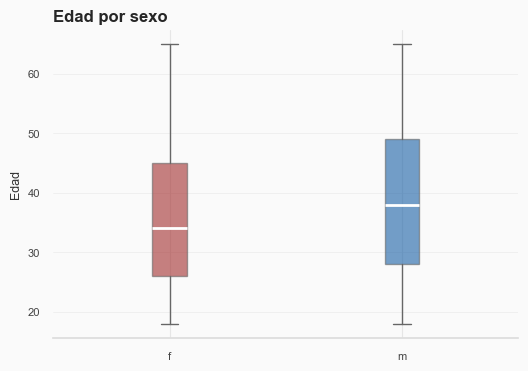

In [10]:
# Boxplot edad por sexo
order = [s for s in ["f", "m"] if s in df["sexo"].unique()]
data = [df[df["sexo"] == s]["edad"] for s in order]
fig, ax = plt.subplots(figsize=(6, 4))
box = ax.boxplot(
    data,
    tick_labels=order,
    patch_artist=True,
    boxprops=dict(linewidth=1, edgecolor="#666"),
    medianprops=dict(color="white", linewidth=2),
    whiskerprops=dict(color="#666"),
    capprops=dict(color="#666"),
    flierprops=dict(marker="o", color="#666", alpha=0.3, markersize=3),
)
for patch, s in zip(box["boxes"], order):
    patch.set_facecolor(C_SEXO.get(s, PALETA[0]))
    patch.set_alpha(0.6)
style_axes(ax, title="Edad por sexo", ylabel="Edad", grid_axis="y")
plt.show()

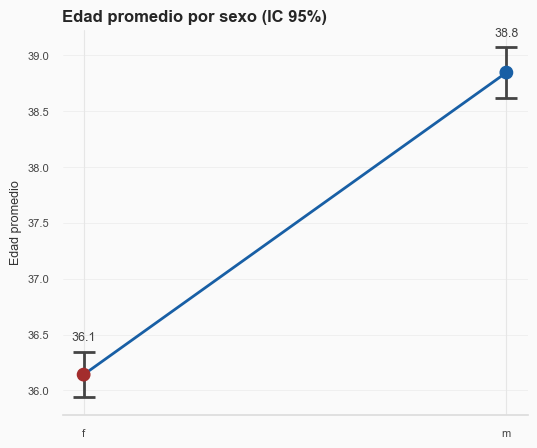

Media mujeres: 36.14 ± 0.20 años
Media hombres: 38.85 ± 0.23 años
Diferencia estadísticamente significativa


In [11]:
# Gráfica de medias — edad por sexo con IC 95%
grupos = df.groupby("sexo")["edad"]
medias_all = grupos.mean()
errores_all = grupos.apply(lambda x: stats.sem(x) * 1.96)
order = [s for s in ["f", "m"] if s in medias_all.index]
medias = medias_all.loc[order]
errores = errores_all.loc[order]
x = np.arange(len(order))

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(x, medias.values, color="#185FA5", linewidth=2, zorder=2)
ax.scatter(
    x, medias.values, color=[C_SEXO.get(s, PALETA[0]) for s in order], s=80, zorder=3
)
ax.errorbar(
    x,
    medias.values,
    yerr=errores.values,
    fmt="none",
    color="#444",
    capsize=8,
    linewidth=2,
    capthick=2,
)
for xi, mean, err in zip(x, medias.values, errores.values):
    ax.text(xi, mean + err + 0.1, f"{mean:.1f}", ha="center", fontsize=9, color="#444")
ax.set_xticks(x)
ax.set_xticklabels(order)
style_axes(
    ax, title="Edad promedio por sexo (IC 95%)", ylabel="Edad promedio", grid_axis="y"
)
plt.show()

t_stat, p_val = stats.ttest_ind(
    df[df["sexo"] == "m"]["edad"], df[df["sexo"] == "f"]["edad"]
)
print(
    f"Media mujeres: {medias_all.get('f',np.nan):.2f} ± {errores_all.get('f',np.nan):.2f} años"
)
print(
    f"Media hombres: {medias_all.get('m',np.nan):.2f} ± {errores_all.get('m',np.nan):.2f} años"
)
print(
    "Diferencia estadísticamente significativa" if p_val < 0.05 else "No significativa"
)

> **Hallazgo — Perfil demográfico:** Los hombres donan a los ~38.8 años y las mujeres a los ~36.1 años. La diferencia de 2.7 años es estadísticamente significativa (p < 0.05) con intervalos de confianza estrechos (±0.20 y ±0.23) dado el tamaño del dataset. Para Sanghelios esto sugiere segmentar por **canal de comunicación más que por edad**: mujeres jóvenes (~36 años) responden mejor a redes sociales y universidades; hombres de mediana edad (~39 años) se alcanzan mejor vía empresas y lugares de trabajo.

### 2.4 Grupos sanguíneos

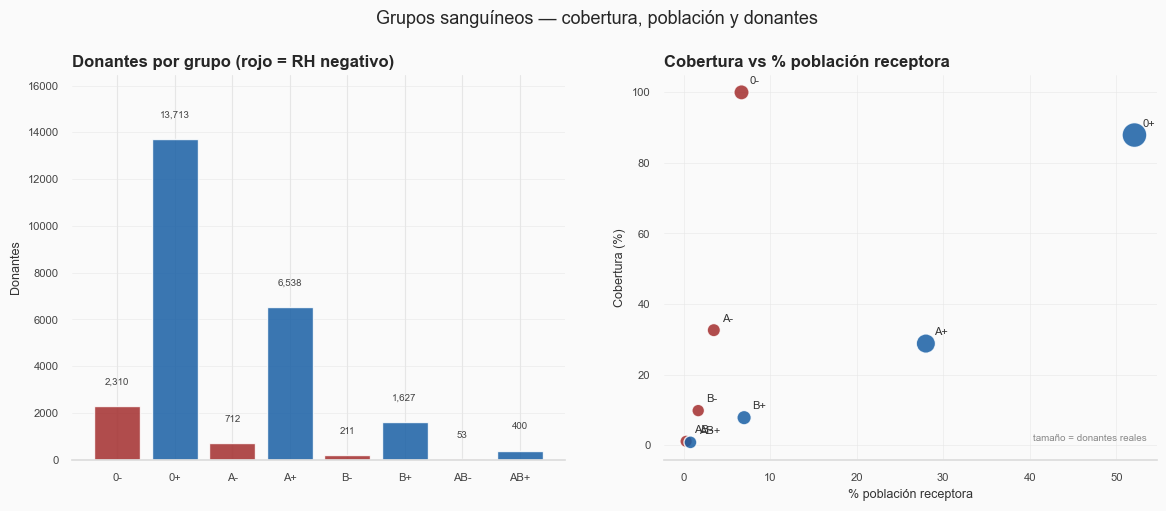

In [12]:
# Cobertura, población receptora y donantes reales por RH
rh_stats = (
    df.groupby("rh")
    .agg(
        donantes=("rh", "count"),
        cobertura=("cobertura", "first"),
        pct_poblacion=("pct_poblacion", "first"),
    )
    .reset_index()
    .sort_values("cobertura", ascending=False)
)
colores_rh = ["#A32D2D" if "-" in r else "#185FA5" for r in rh_stats["rh"]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Grupos sanguíneos — cobertura, población y donantes",
    fontsize=13,
    fontweight="500",
    y=1.01,
)

# Donantes por grupo
bars = axes[0].bar(rh_stats["rh"], rh_stats["donantes"], color=colores_rh, alpha=0.85)
label_bars(
    axes[0],
    bars,
    labels=[f"{v:,}" for v in rh_stats["donantes"]],
    offset_ratio=0.06,
    fontsize=7,
)
axes[0].margins(y=0.2)
style_axes(
    axes[0],
    title="Donantes por grupo (rojo = RH negativo)",
    ylabel="Donantes",
    grid_axis="y",
)

# Scatter cobertura vs % población
sizes = rh_stats["donantes"].to_numpy()
size_scaled = 80 + (sizes - sizes.min()) / (sizes.max() - sizes.min() + 1e-9) * 240
axes[1].scatter(
    rh_stats["pct_poblacion"],
    rh_stats["cobertura"],
    s=size_scaled,
    color=colores_rh,
    alpha=0.85,
    edgecolor="white",
    zorder=3,
)
for i, row in rh_stats.reset_index(drop=True).iterrows():
    axes[1].annotate(
        row["rh"],
        xy=(row["pct_poblacion"], row["cobertura"]),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=8,
        color="#333",
    )
style_axes(
    axes[1],
    title="Cobertura vs % población receptora",
    xlabel="% población receptora",
    ylabel="Cobertura (%)",
    grid_axis="both",
)
axes[1].text(
    0.98,
    0.05,
    "tamaño = donantes reales",
    transform=axes[1].transAxes,
    fontsize=7,
    color="#888",
    ha="right",
)
plt.show()

> **Hallazgo — Grupos sanguíneos:** O+ domina con 13.713 donantes (cobertura 87.9%, 52.1% de Medellín puede recibirlo) — es el grupo de mayor impacto en campañas masivas. O- tiene solo 2.310 donantes pero cobertura universal (100%) — cualquier caída en este grupo requiere **alerta inmediata independiente del volumen total**. Los grupos negativos (A-, B-, AB-) son escasos tanto en donantes como en población receptora, pero críticos en emergencias específicas.

### 2.5 Geografía

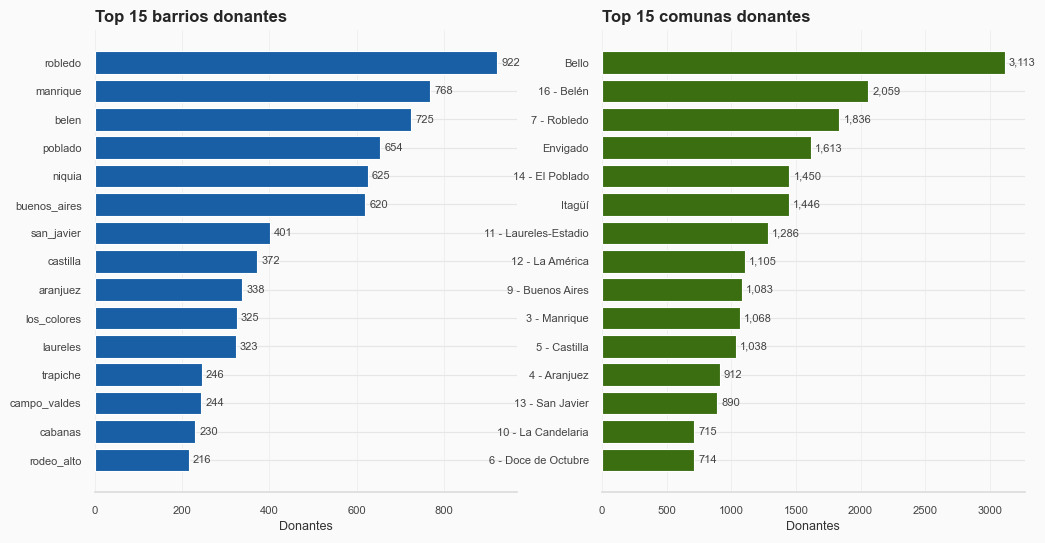

In [13]:
# Top 15 barrios y comunas
top_barrios = df["barrio"].value_counts().head(15).sort_values(ascending=False)
top_comunas = (
    df["comuna_o_municipio"].value_counts().head(15).sort_values(ascending=False)
)
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for ax, data, title, color in zip(
    axes,
    [top_barrios, top_comunas],
    ["Top 15 barrios donantes", "Top 15 comunas donantes"],
    [PALETA[0], PALETA[2]],
):
    bars = ax.barh(
        data.index, data.values, color=color, edgecolor="white", linewidth=0.8
    )
    label_bars(
        ax,
        bars,
        labels=[f"{v:,}" for v in data.values],
        orientation="h",
        offset_ratio=0.01,
    )
    ax.invert_yaxis()
    style_axes(ax, title=title, xlabel="Donantes", grid_axis="x")
plt.show()

### 2.6 Resumen estadístico

In [14]:
print("=" * 55)
print("RESUMEN EDA — Banco de sangre Sanghelios")
print("=" * 55)
print(f"Total donantes:              {len(df):,}")
print(
    f"Período:                     {df['fecha_extraccion'].min().date()} → {df['fecha_extraccion'].max().date()}"
)
print(f"Edad promedio:               {df['edad'].mean():.1f} años")
print(f"IMC promedio:                {df['imc'].mean():.1f}")
print(f"% mujeres:                   {(df['sexo']=='f').mean()*100:.1f}%")
print(f"% hombres:                   {(df['sexo']=='m').mean()*100:.1f}%")
print(f"Grupo RH más común:          {df['rh'].mode()[0]}")
print(f"Barrio top:                  {df['barrio'].mode()[0]}")
print(f"Comuna top:                  {df['comuna_o_municipio'].mode()[0]}")
print(f"% donantes jóvenes (≤35):    {(df['edad']<=35).mean()*100:.1f}%")
print(f"% RH negativo:               {df['rh'].str.contains('-').mean()*100:.1f}%")
print()
print("=" * 55)
print("MÉTRICAS CLAVE PARA ALERTAS — SANGHELIOS")
print("=" * 55)
print(
    f"Donantes O- (universal):        {(df['rh']=='0-').sum():,} ({(df['rh']=='0-').mean()*100:.1f}%)"
)
mes_critico = df.groupby("mes").size().idxmin()
mes_alto = df.groupby("mes").size().idxmax()
print(f"Mes más crítico:                {mes_critico} ({MESES[mes_critico-1]})")
print(f"Mes más alto:                   {mes_alto} ({MESES[mes_alto-1]})")
print(f"Año de mayor escasez:           {df.groupby('año').size().idxmin()}")
normal = df[df["año"].isin([2020, 2021, 2022])].groupby(["año", "mes"]).size().mean()
print(f"Promedio donaciones/mes normal: {normal:.0f}")
print(f"Umbral de alerta sugerido:      < {normal:.0f} donaciones/mes")

RESUMEN EDA — Banco de sangre Sanghelios
Total donantes:              25,564
Período:                     2020-01-02 → 2025-06-27
Edad promedio:               37.4 años
IMC promedio:                26.3
% mujeres:                   55.2%
% hombres:                   44.8%
Grupo RH más común:          0+
Barrio top:                  robledo
Comuna top:                  Bello
% donantes jóvenes (≤35):    48.9%
% RH negativo:               12.9%

MÉTRICAS CLAVE PARA ALERTAS — SANGHELIOS
Donantes O- (universal):        2,310 (9.0%)
Mes más crítico:                12 (Dic)
Mes más alto:                   1 (Ene)
Año de mayor escasez:           2023
Promedio donaciones/mes normal: 496
Umbral de alerta sugerido:      < 496 donaciones/mes


---
## 3. Clustering — K-Prototypes

### Justificación del método

El dataset contiene variables **mixtas**: numéricas (`edad`, `imc`) y categóricas (`rh`, `sexo`, `comuna_o_municipio`). Los métodos evaluados fueron:

| Método | Problema |
|---|---|
| K-Means + OneHotEncoding | OneHotEncoder genera ~1.200 columnas para barrio/comuna, distorsionando pesos |
| DBSCAN | Lento con 25.000 filas y variables mixtas |
| **K-Prototypes** ✓ | Combina distancia euclidiana (numéricas) + Hamming (categóricas) sin expansión |

**Variables excluidas:** `cobertura` y `pct_poblacion` son derivadas de `rh` — cada grupo RH tiene siempre el mismo valor, lo que genera multicolinealidad y distorsiona el clustering.

### 3.1 Selección de k — método del codo

In [15]:
# Preparar datos para K-Prototypes
VARS_CLUSTER = ["edad", "imc", "rh", "sexo", "comuna_o_municipio"]
df_kp = df[VARS_CLUSTER].copy()
cat_idx = [df_kp.columns.get_loc(c) for c in ["rh", "sexo", "comuna_o_municipio"]]
X = df_kp.values

print(f"Variables numéricas:   edad, imc")
print(f"Variables categóricas: rh, sexo, comuna_o_municipio")
print(f"Índices categóricos:   {cat_idx}")
print(f"Shape:                 {X.shape}")

Variables numéricas:   edad, imc
Variables categóricas: rh, sexo, comuna_o_municipio
Índices categóricos:   [2, 3, 4]
Shape:                 (25564, 5)


k=2 → costo: 1,656,293.82
k=3 → costo: 1,047,861.19
k=4 → costo: 844,747.97
k=5 → costo: 745,581.20
k=6 → costo: 661,766.60
k=7 → costo: 597,049.30
k=8 → costo: 551,771.25


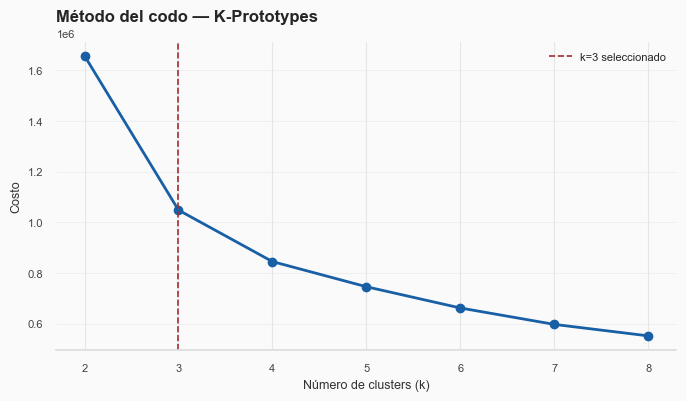

In [17]:
# Curva de codo
costos = []
ks = range(2, 9)
for k in ks:
    kp = KPrototypes(n_clusters=k, init="Huang", n_init=3, random_state=42)
    kp.fit(X, categorical=cat_idx)
    costos.append(kp.cost_)
    print(f"k={k} → costo: {kp.cost_:,.2f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(ks), costos, color=PALETA[0], linewidth=2, marker="o", markersize=6)
ax.axvline(3, color=PALETA[1], linestyle="--", linewidth=1.2, label="k=3 seleccionado")
style_axes(
    ax,
    title="Método del codo — K-Prototypes",
    xlabel="Número de clusters (k)",
    ylabel="Costo",
    grid_axis="y",
)
ax.legend(fontsize=8, frameon=False)
plt.show()

> **Selección k=3:** La mayor caída ocurre de k=2 a k=3 (≈608.000 puntos). De k=3 en adelante la reducción es marginal y no justifica la complejidad adicional. Además k=3 produce perfiles directamente accionables para campañas: joven, adulto y mayor.

### 3.2 Modelo final

In [22]:
# Entrenar K-Prototypes k=3
kp_final = KPrototypes(n_clusters=3, init="Huang", n_init=5, random_state=42, gamma=0.5)
df["cluster"] = kp_final.fit_predict(X, categorical=cat_idx)

print("Tamaño de clusters:")
print(df["cluster"].value_counts().sort_index())
print("\nCentroides:")

centroids = kp_final.cluster_centroids_
if isinstance(centroids, (list, tuple)) and len(centroids) == 2:
    centroids_num = np.asarray(centroids[0], dtype=float)
    centroids_cat = np.asarray(centroids[1])
else:
    centroids = np.asarray(centroids)
    num_idx = [i for i in range(centroids.shape[1]) if i not in cat_idx]
    centroids_num = centroids[:, num_idx].astype(float)
    centroids_cat = centroids[:, cat_idx]

for i, (num, cat) in enumerate(zip(centroids_num, centroids_cat)):
    print(
        f"  Cluster {i}: edad={num[0]:.1f}, imc={num[1]:.1f}, rh={cat[0]}, sexo={cat[1]}, comuna={cat[2]}"
    )

Tamaño de clusters:
cluster
0    6496
1    9966
2    9102
Name: count, dtype: int64

Centroides:
  Cluster 0: edad=54.5, imc=27.0, rh=0+, sexo=m, comuna=Bello
  Cluster 1: edad=24.9, imc=25.3, rh=0+, sexo=f, comuna=Bello
  Cluster 2: edad=38.7, imc=27.0, rh=0+, sexo=f, comuna=Bello


### 3.3 Separación de características por cluster

In [23]:
# Variables numéricas
print("=" * 55)
print("SEPARACIÓN DE CARACTERÍSTICAS POR CLUSTER")
print("=" * 55)
print("\n--- NUMÉRICAS (media | mediana | std) ---")
print(df.groupby("cluster")[["edad", "imc"]].agg(["mean", "median", "std"]).round(2))

# Variables categóricas
print("\n--- CATEGÓRICAS (top 3 por cluster) ---")
for col in ["rh", "sexo", "comuna_o_municipio"]:
    print(f"\n  {col.upper()}:")
    tabla = (
        df.groupby(["cluster", col])
        .size()
        .reset_index(name="n")
        .assign(
            pct=lambda x: x.groupby("cluster")["n"]
            .transform(lambda g: g / g.sum() * 100)
            .round(1)
        )
    )
    print(
        tabla.sort_values(["cluster", "n"], ascending=[True, False])
        .groupby("cluster")
        .head(3)
        .to_string(index=False)
    )

SEPARACIÓN DE CARACTERÍSTICAS POR CLUSTER

--- NUMÉRICAS (media | mediana | std) ---
          edad                 imc             
          mean median   std   mean median   std
cluster                                        
0        54.51   54.0  4.88  27.04  26.56  3.73
1        24.93   25.0  3.91  25.29  24.58  3.99
2        38.72   39.0  4.17  27.02  26.45  4.00

--- CATEGÓRICAS (top 3 por cluster) ---

  RH:
 cluster rh    n  pct
       0 0+ 3536 54.4
       0 A+ 1564 24.1
       0 0-  692 10.7
       1 0+ 5355 53.7
       1 A+ 2598 26.1
       1 0-  773  7.8
       2 0+ 4822 53.0
       2 A+ 2376 26.1
       2 0-  845  9.3

  SEXO:
 cluster sexo    n  pct
       0    m 3283 50.5
       0    f 3213 49.5
       1    f 6118 61.4
       1    m 3848 38.6
       2    f 4778 52.5
       2    m 4324 47.5

  COMUNA_O_MUNICIPIO:
 cluster comuna_o_municipio    n  pct
       0              Bello  711 10.9
       0         16 - Belén  650 10.0
       0        7 - Robledo  452  7.0
       

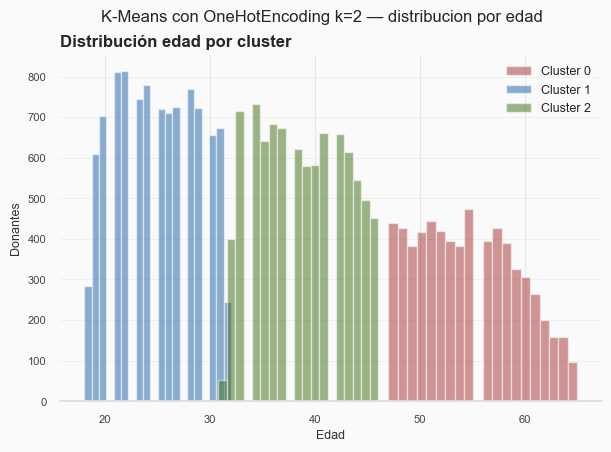

In [30]:
# Distribuciones por cluster
fig, ax = plt.subplots(figsize=(7, 4.5))

colores = {0: "#A32D2D", 1: "#185FA5", 2: "#3B6D11"}

# Edad por cluster
for c in sorted(df["cluster"].unique()):
    datos = df[df["cluster"] == c]["edad"]
    ax.hist(
        datos,
        bins=20,
        alpha=0.5,
        color=colores.get(c, colores[0]),
        label=f"Cluster {c}",
        edgecolor="white",
    )

style_axes(
    ax,
    title="Distribución edad por cluster",
    xlabel="Edad",
    ylabel="Donantes",
    grid_axis="y",
)
ax.legend(fontsize=9, frameon=False)
fig.suptitle(
    "K-Means con OneHotEncoding k=2 — distribucion por edad",
    fontsize=12,
    fontweight="500",
)
plt.show()

### 3.4 Conclusiones del clustering

**La edad es la única variable que separa los clusters de forma clara y significativa.**

| Cluster | Perfil | Edad media | Rango | Sexo dominante | Canal campaña |
|---|---|---|---|---|---|
| 1 | Joven | 24.9 años | 18–32 | Mujeres (61.4%) | Redes sociales, universidades |
| 2 | Adulto | 38.7 años | 32–47 | Mujeres (52.5%) | WhatsApp, empresas |
| 0 | Mayor | 54.5 años | 47–65 | Hombres (50.5%) | Radio, llamadas, consultorios |

**RH, IMC y comuna no diferencian los clusters** — los tres grupos tienen siempre O+ como grupo dominante (~53–54%), distribución de IMC similar (~25–27) y las mismas comunas top (Bello, Belén, Robledo). El dataset no tiene suficiente variación en esas variables para generar perfiles distintos entre grupos de edad.

**Implicación para Sanghelios:** el criterio de segmentación para campañas debe ser la **edad**, no el grupo sanguíneo ni la ubicación geográfica. El canal de comunicación debe cambiar por grupo etario, no el mensaje de fondo. Adicionalmente, O- requiere una **alerta especial permanente** independiente de cualquier cluster dado su impacto universal.

### 3.5 Guardar dataset con cluster

In [31]:
# Agregar nombre descriptivo del perfil
rangos = df.groupby("cluster")["edad"].mean()
nombres = {
    c: ("Joven (18-32)" if m < 32 else "Adulto (32-47)" if m < 45 else "Mayor (47-65)")
    for c, m in rangos.items()
}
df["perfil"] = df["cluster"].map(nombres)

# Guardar en data/processed
project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

output_dir = project_root / "data" / "processed"
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / "df_banco_sangre_con_cluster.csv"

df.to_csv(output_path, index=False)
print(f"Archivo guardado: {output_path}")
print(f"Columnas: {df.columns.tolist()}")
print("\nDistribucion final:")
print(
    df.groupby(["cluster", "perfil"])
    .size()
    .reset_index(name="donantes")
    .to_string(index=False)
)

Archivo guardado: c:\Users\jomig\p-REDbloodDON\p-REDbloodDON\data\processed\df_banco_sangre_con_cluster.csv
Columnas: ['fecha_extraccion', 'rh', 'barrio', 'comuna_o_municipio', 'edad', 'sexo', 'cobertura', 'pct_poblacion', 'imc', 'año', 'mes', 'cluster', 'perfil']

Distribucion final:
 cluster         perfil  donantes
       0  Mayor (47-65)      6496
       1  Joven (18-32)      9966
       2 Adulto (32-47)      9102
